In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [22]:
data=pd.read_csv("/content/house_price_synthetic_dataset.csv")

In [3]:
data.head()

,Area_sqft,Bedrooms,Bathrooms,Location,Floors,Parking,House_Age,Price_Lakhs
0,1660.0,3,NaN,Pune,2.0,1.0,14.0,142.58
1,2094.0,1,2.0,Bangalore,1.0,2.0,20.0,124.73
2,1930.0,4,3.0,Mumbai,NaN,0.0,18.0,185.71
3,1895.0,2,1.0,Pune,3.0,0.0,6.0,119.95
4,2438.0,5,5.0,Delhi,1.0,2.0,NaN,212.38


In [4]:
data.shape

(500, 8)

In [5]:
data.describe()

,Area_sqft,Bedrooms,Bathrooms,Floors,Parking,House_Age,Price_Lakhs
count,490.000000,500.000000,490.000000,487.000000,490.000000,489.000000,500.000000
mean,2155.081633,2.982000,3.006122,1.969199,0.948980,13.096115,161.143400
std,740.983968,1.458056,1.447783,0.812123,0.800977,6.915841,40.255689
min,801.000000,1.000000,1.000000,1.000000,0.000000,1.000000,57.300000
25%,1548.500000,2.000000,2.000000,1.000000,0.000000,7.000000,132.355000
50%,2158.500000,3.000000,3.000000,2.000000,1.000000,13.000000,159.595000
75%,2749.000000,4.000000,4.000000,3.000000,2.000000,19.000000,189.592500
max,3495.000000,5.000000,5.000000,3.000000,2.000000,24.000000,278.950000


In [6]:
data.isnull().sum()

,0
Area_sqft,10
Bedrooms,0
Bathrooms,10
Location,10
Floors,13
Parking,10
House_Age,11
Price_Lakhs,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area_sqft    490 non-null    float64
 1   Bedrooms     500 non-null    int64  
 2   Bathrooms    490 non-null    float64
 3   Location     490 non-null    object 
 4   Floors       487 non-null    float64
 5   Parking      490 non-null    float64
 6   House_Age    489 non-null    float64
 7   Price_Lakhs  500 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 31.4+ KB


In [8]:
data.describe()

,Area_sqft,Bedrooms,Bathrooms,Floors,Parking,House_Age,Price_Lakhs
count,490.000000,500.000000,490.000000,487.000000,490.000000,489.000000,500.000000
mean,2155.081633,2.982000,3.006122,1.969199,0.948980,13.096115,161.143400
std,740.983968,1.458056,1.447783,0.812123,0.800977,6.915841,40.255689
min,801.000000,1.000000,1.000000,1.000000,0.000000,1.000000,57.300000
25%,1548.500000,2.000000,2.000000,1.000000,0.000000,7.000000,132.355000
50%,2158.500000,3.000000,3.000000,2.000000,1.000000,13.000000,159.595000
75%,2749.000000,4.000000,4.000000,3.000000,2.000000,19.000000,189.592500
max,3495.000000,5.000000,5.000000,3.000000,2.000000,24.000000,278.950000


In [9]:
data.nunique()

,0
Area_sqft,422
Bedrooms,5
Bathrooms,5
Location,6
Floors,3
Parking,3
House_Age,24
Price_Lakhs,471


In [12]:
data['Location'].unique()

array(['Pune', 'Bangalore', 'Mumbai', 'Delhi', 'Hyderabad', 'Chennai',
       nan], dtype=object)

In [14]:
data['Location'].value_counts()

,count
Location,
Hyderabad,93
Delhi,92
Chennai,86
Bangalore,79
Pune,77
Mumbai,63


In [10]:
(data.isnull().sum()/len(data))*100

,0
Area_sqft,2.0
Bedrooms,0.0
Bathrooms,2.0
Location,2.0
Floors,2.6
Parking,2.0
House_Age,2.2
Price_Lakhs,0.0


In [16]:
data = pd.get_dummies(data, drop_first=True)

In [17]:
data.drop_duplicates(inplace=True)

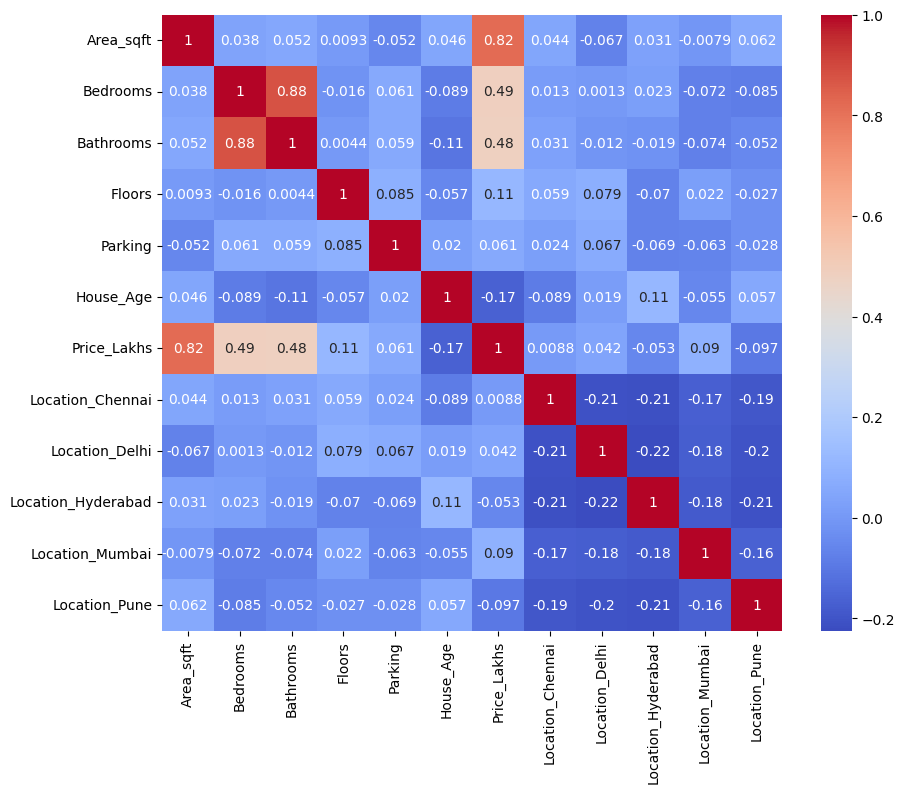

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

In [31]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])
model = Pipeline([
    ("preprocessor", preprocessor),
    ("linear_regression", LinearRegression())
])

In [29]:
X = data.drop("Price_Lakhs", axis=1)
y = data["Price_Lakhs"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Area_sqft', 'Bedrooms',
                                                   'Bathrooms', 'Floors',
                                                   'Parking', 'House_Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Location'])])),
                ('linear_regression', LinearRegression())])

In [33]:
y_pred = model.predict(X_test)


In [34]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:",mse)

MSE: 115.75818137638932


In [35]:
rmse = np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 10.759097609762136


In [38]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:",mae)

MAE: 7.39504584573437


In [39]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:",r2)

R2 Score: 0.9326309040331167


<Axes: xlabel='Price_Lakhs'>

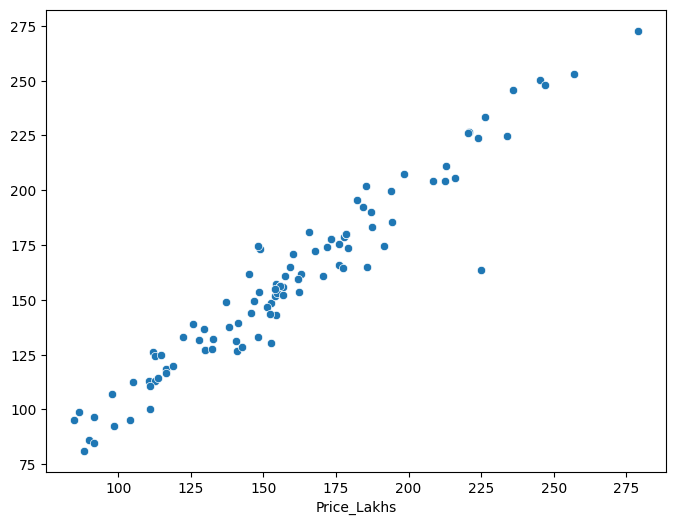

In [40]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)


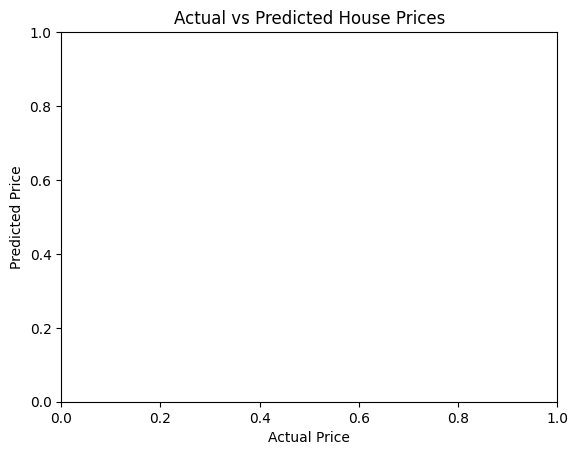

In [41]:
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

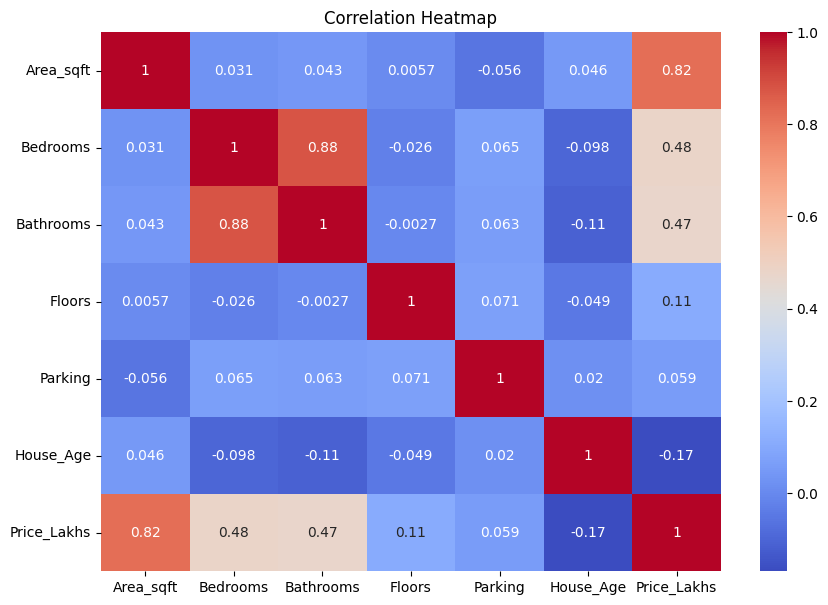

In [43]:
plt.figure(figsize=(10,7))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [44]:
data.to_csv("cleaned_dataset.csv", index=False)